In [7]:
import torch, timm, cv2, os, glob
import torch.nn as nn
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision import transforms
from PIL import Image
import random
from pathlib import Path

In [8]:
# ── mirror your bot script exactly ──────────────────────
MODEL_PATH   = "../models/mobilenet_tiny_torchscript.pt"   # ← change if needed
IMAGE_DIR    = "../../data/dataset_images/"                               # ← folder with your test images
IMAGE_GLOB   = "*.png"                                     # ← or *.png, *.jpeg …

MAX_SPEED    = 0.3
LEFT_SCALE   = 1.0
RIGHT_SCALE  = 0.98
TURN_BOOST   = 0.4
TURN_POWER   = 0.8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Export to ONNX

In [9]:
model_name = 'timm/mobilenetv4_conv_small_050.e3000_r224_in1k'
model = timm.create_model(model_name, pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Linear(1280, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 2),
    nn.Tanh()
)
model = model.to(device)

checkpoint = torch.load("../models/mobilenet_tiny", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval();

dummy = torch.zeros(1, 3, 224, 224).to(device)
torch.onnx.export(model, dummy, "../models/tiny_mobilenet.onnx", input_names=["x"], opset_version=11);

In [10]:
import onnx
model_check = onnx.load("../models/tiny_mobilenet.onnx")
onnx.checker.check_model(model_check)
print("IR version:", model_check.ir_version)
print("Opset:", model_check.opset_import[0].version)
print("Model is valid!")

IR version: 6
Opset: 11
Model is valid!


## Load ONNX model

In [11]:
onnx_session = ort.InferenceSession("../models/tiny_mobilenet.onnx")

# inspect expected input name and shape
print(onnx_session.get_inputs()[0].name)   # usually 'input' or 'x'
print(onnx_session.get_inputs()[0].shape)  # [1, 3, 224, 224]

x
[1, 3, 224, 224]


## Inference

In [5]:
image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, IMAGE_GLOB)))
print(f"Found {len(image_paths)} images")

Found 1950 images


In [6]:
def preprocess(img):
    # uint8 [0,255] → float32 [0,1]
    img = img.astype(np.float32) / 255.0
    # normalize with mean=0.5 std=0.5  →  [-1, 1]
    img = (img - 0.5) / 0.5
    # HWC → CHW → NCHW
    img = img.transpose(2, 0, 1)[np.newaxis]
    return np.ascontiguousarray(img)

In [7]:
def _counter(c=[0]): v = c[0]; c[0] += 1; return v

Raw model output:
  throttle : +0.7582
  turn     : -0.5956



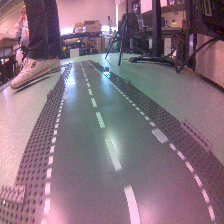

In [8]:
INSPECT_IDX = _counter()

path    = image_paths[INSPECT_IDX]
raw_bgr = cv2.imread(path)
raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
pil_img = Image.fromarray(raw_rgb)

x = preprocess(raw_rgb)
output = onnx_session.run(None, {"x": x})

throttle_raw, turn_raw = output[0][0]

print(f"Raw model output:")
print(f"  throttle : {throttle_raw:+.4f}")
print(f"  turn     : {turn_raw:+.4f}")

# Sanity checks
print()
if abs(throttle_raw) < 0.01 and abs(turn_raw) < 0.01:
    print("⚠️  Both outputs near zero — model may not be loaded correctly, or input is wrong.")
if abs(throttle_raw) > 0.99 or abs(turn_raw) > 0.99:
    print("⚠️  Output saturated at ±1.0 — check if Tanh is applied inside the model or outside.")
if throttle_raw < 0:
    print("⚠️  Negative throttle — robot would drive backward.")
pil_img

## Stats

In [9]:
results = []

for path in image_paths:
    raw_bgr = cv2.imread(path)
    raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(raw_rgb)
    x       = preprocess(raw_rgb)

    out = onnx_session.run(None, {"x": x})

    t, r = out[0][0]
    results.append({"path": path, "throttle": t, "turn": r})

throttles = [r["throttle"] for r in results]
turns     = [r["turn"]     for r in results]

# print(f"{'Image':<35} {'Throttle':>9} {'Turn':>9}")
# print("-" * 55)
# for r in results:
#     name = Path(r["path"]).name
#     print(f"{name:<35} {r['throttle']:+9.4f} {r['turn']:+9.4f}")

print()
print("── Statistics ──────────────────────────────")
print(f"Throttle   mean={np.mean(throttles):+.3f}  std={np.std(throttles):.3f}  "
      f"min={np.min(throttles):+.3f}  max={np.max(throttles):+.3f}")
print(f"Turn       mean={np.mean(turns):+.3f}  std={np.std(turns):.3f}  "
      f"min={np.min(turns):+.3f}  max={np.max(turns):+.3f}")


── Statistics ──────────────────────────────
Throttle   mean=+0.793  std=0.162  min=+0.164  max=+0.993
Turn       mean=-0.149  std=0.188  min=-0.945  max=+0.117


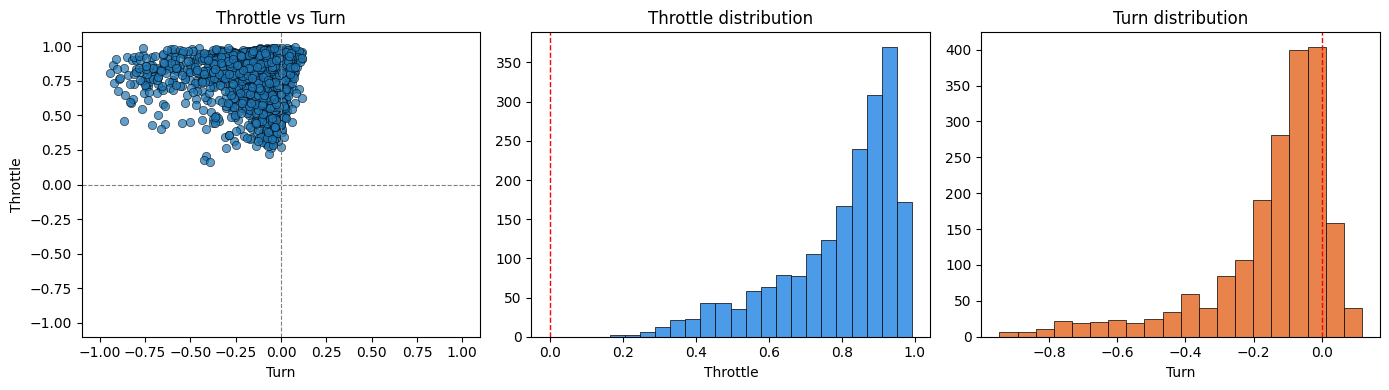

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Scatter: throttle vs turn
axes[0].scatter(turns, throttles, alpha=0.7, edgecolors="k", linewidths=0.5)
axes[0].axhline(0, color="gray", lw=0.8, ls="--")
axes[0].axvline(0, color="gray", lw=0.8, ls="--")
axes[0].set_xlabel("Turn"); axes[0].set_ylabel("Throttle")
axes[0].set_title("Throttle vs Turn")
axes[0].set_xlim(-1.1, 1.1); axes[0].set_ylim(-1.1, 1.1)

# Histogram: throttle
axes[1].hist(throttles, bins=20, color="#4C9BE8", edgecolor="k", linewidth=0.5)
axes[1].axvline(0, color="red", lw=1, ls="--")
axes[1].set_xlabel("Throttle"); axes[1].set_title("Throttle distribution")

# Histogram: turn
axes[2].hist(turns, bins=20, color="#E8834C", edgecolor="k", linewidth=0.5)
axes[2].axvline(0, color="red", lw=1, ls="--")
axes[2].set_xlabel("Turn"); axes[2].set_title("Turn distribution")

plt.tight_layout(); plt.show()


In [11]:
def motor_mix(throttle, turn,
              max_speed=MAX_SPEED, left_scale=LEFT_SCALE,
              right_scale=RIGHT_SCALE, turn_boost=TURN_BOOST):
    """Exact replication of the mixing block from the bot script."""
    base_throttle    = throttle
    turn_component   = turn * turn_boost
    left_trigger_c   = 0.0
    right_trigger_c  = 0.0

    left_motor  = (left_trigger_c  + base_throttle + turn_component) * max_speed * left_scale
    right_motor = (right_trigger_c + base_throttle - turn_component) * max_speed * right_scale

    left_motor  = max(-1.0, min(1.0, left_motor))
    right_motor = max(-1.0, min(1.0, right_motor))
    return left_motor, right_motor

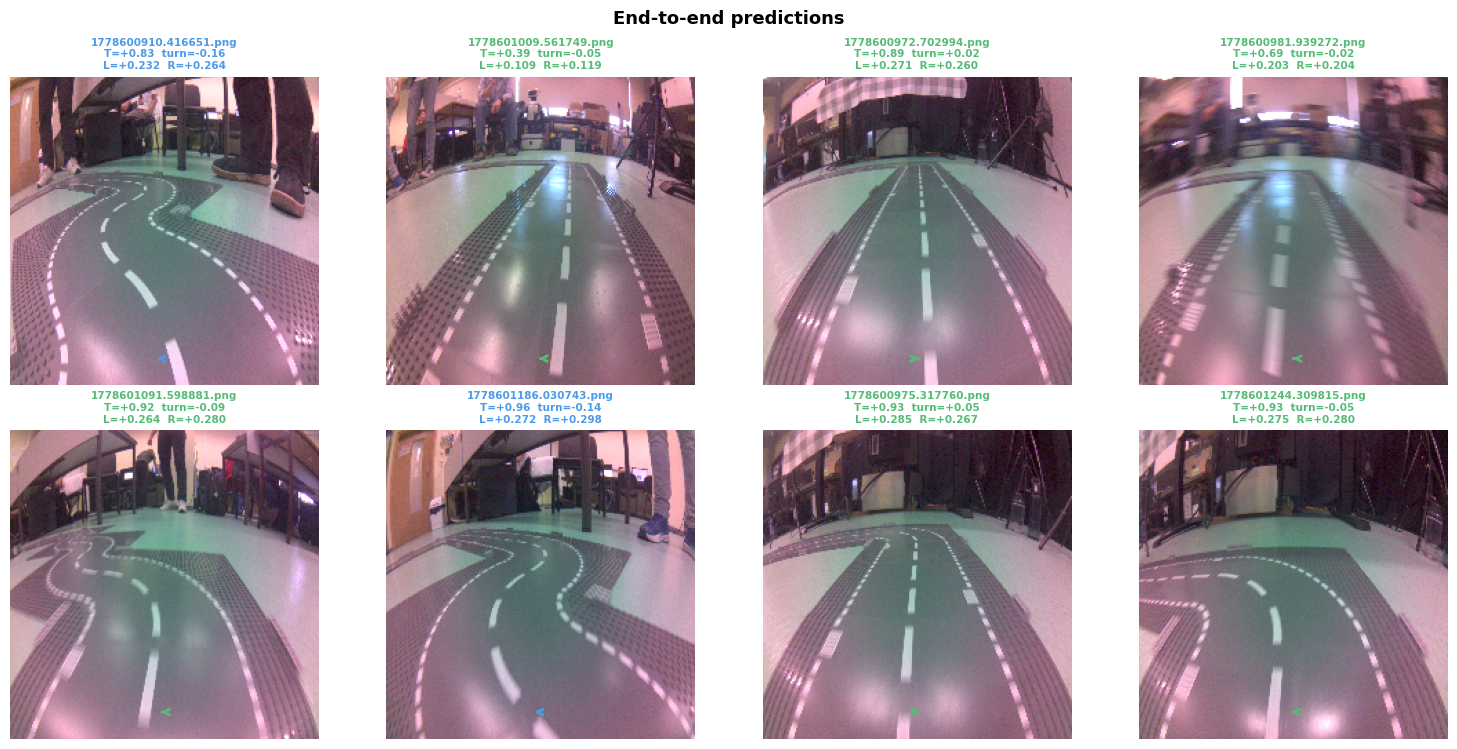

In [12]:
n_show = min(8, len(image_paths))
cols   = 4
rows   = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.8, rows * 3.8))
axes = np.array(axes).flatten()

for ax in axes:
    ax.axis("off")

selected_paths = random.sample(
    image_paths,
    min(n_show, len(image_paths))
)

for i, path in enumerate(selected_paths):
    raw_bgr = cv2.imread(path)
    raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(raw_rgb)
    x       = preprocess(raw_rgb)

    out = onnx_session.run(None, {"x": x})

    thr, trn = out[0][0]
    l, r = motor_mix(thr, trn)

    # colour-code by turn direction
    colour = "#E8834C" if trn > 0.1 else ("#4C9BE8" if trn < -0.1 else "#55BB77")

    axes[i].imshow(raw_rgb)
    axes[i].set_title(
        f"{Path(path).name}\n"
        f"T={thr:+.2f}  turn={trn:+.2f}\n"
        f"L={l:+.3f}  R={r:+.3f}",
        fontsize=7.5, color=colour, fontweight="bold"
    )
    axes[i].axis("off")

    # draw a small arrow showing steering direction
    cx, cy = raw_rgb.shape[1] // 2, raw_rgb.shape[0] - 20
    arrow_len = int(raw_rgb.shape[1] * 0.25 * abs(trn))
    dx = int(arrow_len * np.sign(trn))
    axes[i].annotate("", xy=(cx + dx, cy), xytext=(cx, cy),
                     arrowprops=dict(arrowstyle="->", color=colour, lw=2))

plt.suptitle("End-to-end predictions", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
